<a href="https://colab.research.google.com/github/RaquelHernanz/BachelorsThesis_SyntheticClinicalData/blob/master/NOTEBOOK3_BTSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 3 — Outlier Detection and Clinical Plausibility Audit**

- **Author:** Raquel Hernanz Hernández
- **Supervisors:** José María Herrera and Guillermo José Ortega
- **Degree:** Biomedical Engineering  
- **Project:** Bachelor Thesis — *Generation and Validation of Synthetic Data from a Hospital Emergency Department*

## Role in the pipeline

| Notebook | Purpose |
|----------|---------|
| NB1 | Data loading, cleaning, column removal, binary re-encoding, export |
| NB2 | Exploratory Data Analysis (distributions, clustering, feature screening) |
| **NB3 (this)** | Outlier detection and clinical plausibility audit |
| NB4 | VIF analysis, logistic regression, clinical risk scoring system |

## Objective

**Notebook 3 (NB3)** provides the tools for identifying and characterising anomalous observations in clinically meaningful numeric variables using two complementary distance-based methods:

1. **KNN outlier scoring** — flags globally isolated observations based on mean Manhattan distance to k nearest neighbours.
2. **Density-in-Radius (DRR)** — flags locally isolated observations based on neighbour count within a fixed radius.
3. **Isolation Forest (IF)** — flags anomalous observations by recursively partitioning the feature space with random axis-aligned cuts; observations that require fewer splits to be isolated receive a higher anomaly score, making it particularly effective for detecting global outliers in high-dimensional spaces without relying on distance metrics.

Detected outliers are then subjected to:

4. **Plausibility audit** — cross-variable coherence checks (e.g., TAS ≥ TAD, MAP consistency, oxygenation patterns).
5. **Driver analysis** — robust z-scores identify which variables contribute most to each outlier's anomalous profile.

## Input / Output

| | File | Description |
|---|---|---|
| **Input** | `dataset_FINAL.csv` | Cleaned dataset exported by NB1 |
| **Input** | `TABLA_ATRIBUTOS_ACTUALIZADO.xlsx` | Attribute reference table (variable types, ranges) |
| **Output** | — | Diagnostic plots, audit tables, outlier flags (analysis only, no file export) |

## **1. Libraries**

| Library | Role |
|---------|------|
| `pandas`, `numpy` | Data handling and numeric operations |
| `matplotlib` | Diagnostic visualisations (histograms, scatter plots, profile charts) |
| `sklearn.impute.SimpleImputer` | Median imputation of missing values before distance computation (outlier detection only — does not modify the source dataset) |
| `sklearn.preprocessing.RobustScaler` | IQR-based feature scaling, chosen over `StandardScaler` because it is less sensitive to the very outliers we are trying to detect |
| `sklearn.pipeline.Pipeline` | Chains imputation + scaling into a single reproducible preprocessing step |
| `sklearn.neighbors.NearestNeighbors` | Efficient k-NN and radius-based neighbour queries (ball-tree / KD-tree backend) |
| `sklearn.ensemble.IsolationForest` | Isolation Forest anomaly detector: fits an ensemble of isolation trees and assigns an anomaly score to each observation; robust to high-dimensional mixed-distribution data and does not require distance metric tuning |

> No modelling libraries are imported, logistic regression and feature selection are handled in **NB4**.

In [ ]:
from __future__ import annotations

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, List, Optional, Sequence, Tuple

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest

from IPython.display import display, Markdown

# Global settings
np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

### Global plot style

All figures in this notebook use the **TFG unified style**, a `theme_bw()`-equivalent
for matplotlib/seaborn inspired by **Zhang Z et al. (2017)** *Development of scoring
system for risk stratification in clinical medicine*.

**Key visual conventions:**
- White background, light grey grid, thin black panel border.
- Serif font family for a clinical publication feel.
- Consistent colour palette: `TFG_COLORS` dict (gold/sky-blue for outcome bars,
  red/green for mortality leaf overlays, blue for model curves).
- Output quality: 100 dpi screen, 150 dpi saved figures.

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ── TFG Unified Plot Style (Zhang et al. 2017 – theme_bw equivalent) ─────────
TFG_STYLE = {
    "axes.facecolor":    "white",
    "figure.facecolor":  "white",
    "axes.edgecolor":    "black",
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        "#d9d9d9",
    "grid.linewidth":    0.5,
    "grid.linestyle":    "-",
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   9,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#cccccc",
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  4,
    "ytick.major.size":  4,
    "figure.dpi":        100,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
}
mpl.rcParams.update(TFG_STYLE)
sns.set_theme(style="white", rc=TFG_STYLE)

# ── TFG Colour Palette ────────────────────────────────────────────────────────
TFG_COLORS = {
    "loess_curve":       "#3366CC",
    "loess_band":        "#B0C4DE",
    "cutpoint":          "#2ca02c",
    "ref_line":          "#d62728",
    "survivors":         "#FFD700",
    "non_survivors":     "#87CEEB",
    "dead_leaf":         "#d62728",
    "alive_leaf":        "#4CAF50",
    "pred_prob_line":    "black",
    "pred_prob_ci":      "#d62728",
    "ideal_line":        "#888888",
    "calib_curve":       "black",
    "jitter_pts":        "#555555",
    "inliers":           "#aec6cf",
    "cluster_0":         "#0072B2",   # Wong deep blue
    "cluster_1":         "#E69F00",   # Wong amber
    "cluster_2":         "#009E73",   # Wong teal green
    "cluster_consensus": "#404040",
}


## **2. Shared configuration**

### Parameters

Identical to **NB1** and **NB2**. See NB1 Section 2 for detailed descriptions.

| Parameter | Value | Relevant here? |
|-----------|-------|----------------|
| `RANDOM_STATE` | `42` | Yes — seeding for reproducible neighbour queries |
| `TARGET_COL` | `Mort. 30D`, `Mort. 7D`, `Mort. 2D` | No — outlier detection is unsupervised |
| `CLEAN_DATA_PATH` | (see code) | Yes — input file |
| `ATTR_TABLE_PATH` | (see code) | Yes — selects numeric variables and cross-checks plausible ranges |

In [ ]:
# ══════════════════════════════════════════════════════════════
# SHARED CONFIGURATION (replicated from NB1)
# ══════════════════════════════════════════════════════════════

RANDOM_STATE   = 42
TARGET_COL     = "Mort. 30D"
ALL_MORT_COLS  = ["Mort. 2D", "Mort. 7D", "Mort. 30D"]

# --- File paths (edit per environment) ---
CLEAN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/TFG/dataset_FINAL.csv"
ATTR_TABLE_PATH = "/content/drive/MyDrive/Colab Notebooks/TFG/TABLA_ATRIBUTOS_ACTUALIZADO.xlsx"

# --- Colab Google Drive mount ---
try:
    from google.colab import drive
    from pathlib import Path
    if not Path("/content/drive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

# --- Output directory (created after Drive mount) ---
NB3_OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/TFG/PREPROCESSING/NB3_OUTLIERS"
os.makedirs(NB3_OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


## **3. Data loading**

1. Load the cleaned CSV exported by **NB1**.
2. Load the attribute reference table, used to programmatically identify which columns are strictly numeric (vital signs and lab values) and to retrieve plausible ranges for the coherence audit.

### Input

| File | Variable | Description |
|------|----------|-------------|
| `dataset_FINAL.csv` | `df` | Main working DataFrame |
| `TABLA_ATRIBUTOS_ACTUALIZADO.xlsx` | `attribute_table` | Metadata table with column types, units, and ranges |

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `df` | `pd.DataFrame` | Cleaned dataset (unchanged — all operations in this notebook are read-only) |
| `attribute_table` | `pd.DataFrame` | Reference table for variable selection |

In [ ]:
df = pd.read_csv(CLEAN_DATA_PATH)
df.columns = df.columns.astype(str).str.strip()

attribute_table = pd.read_excel(ATTR_TABLE_PATH)

display(Markdown(f"**Dataset:** {df.shape[0]} rows × {df.shape[1]} columns"))
display(df.head(3))

display(Markdown("**Attribute table:**"))
display(attribute_table[["Atributo", "Tipo de valor", "Rango/Soporte"]].head(20))

**Dataset:** 2376 rows × 33 columns

,Edad,Sexo,FR,SpO2,O2,TAS,TAD,TAM,FC,TT,GCS.O,GCS.V,GCS.M,GCS,Lactato,Glucemia,Ritmo,ST,O2 sup.,FiO2,Gafas,Venturi,Resrv.,Nebul.,VNI,IOT,VAD,VM,MAVA,TTE,Mort. 2D,Mort. 7D,Mort. 30D
0,87,1,23,76,1,82,49,60.000000,88,34.9,4,5,6,15,5.3,166,1,1,1,0.5,0,0,1,0,0,0,0,0,0,0,1,1,1
1,87,0,34,85,1,233,126,161.666667,105,36.7,4,5,6,15,2.2,148,5,1,1,0.5,0,0,1,1,0,0,0,0,0,0,0,0,0
2,88,1,6,50,1,193,106,135.000000,117,38.2,4,4,6,14,5.6,131,5,6,1,0.5,0,0,1,1,0,0,0,0,0,0,0,0,0


**Attribute table:**

,Atributo,Tipo de valor,Rango/Soporte
0,Edad,int,≥0
1,Sexo,int (categórica),1–2
2,FR,int,≥0
3,SpO2,int,0–100
4,O2,int (binaria),1–2
5,TAS,int,≥0
6,TAD,int,≥0
7,TAM,float,≥0
8,FC,int,≥0
9,TT,float,—


## **4. Numeric variable selection and preprocessing**

Outlier detection is restricted to **strictly numeric prehospital variables** — vital signs and lab values whose deviations have direct clinical meaning. Categorical, binary, ordinal, and datetime columns are excluded because distance-based outlier scores are not meaningful for discrete or bounded scales.

Variable selection is driven by the attribute table rather than hardcoded lists: any column whose value type matches `int` or `float` (excluding and `GCS` subcomponents or categorical features) is included. GCS subcomponents (`GCS.O`, `GCS.V`, `GCS.M`) are excluded because they are ordinal with very few levels (3–6), making distance-based methods unreliable; the total GCS score is also excluded for the same reason.

### Function: `get_numeric_columns_from_attribute_table()`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `attribute_table` | `pd.DataFrame` | — | Reference table |
| `attribute_col` | `str` | `"Attribute"` | Column containing variable names |
| `type_col` | `str` | `"Type of value"` | Column containing type labels |
| `exclude_regex` | `str` | `r"(?i)^(fecha\|gcs)"` | Regex to exclude datetime and GCS variables |
| **Returns** | `List[str]` | | List of numeric column names |

### Function: `preprocess_numeric_matrix()`

| Parameter | Type | Description |
|-----------|------|-------------|
| `df` | `pd.DataFrame` | Input dataset |
| `numeric_cols` | `List[str]` | Columns to preprocess |
| **Returns** | `Tuple[np.ndarray, List[str], Pipeline]` | Scaled matrix `X`, used column names, fitted pipeline |

**Pipeline steps**:

| Step | Method | Justification |
|------|--------|---------------|
| 1. Imputation | `SimpleImputer(strategy="median")` | Median is robust to the skewed distributions typical of clinical vital signs (e.g., Lactato, Glucemia) |
| 2. Scaling | `RobustScaler()` | Uses median and IQR instead of mean and std, reducing the influence of the very outliers we are trying to detect |

> Distance-based methods (KNN, DRR) are sensitive to feature scale. Without scaling, variables measured in mmHg (0–260) would dominate those measured in mmol/L (0–25). `RobustScaler` is preferred over `StandardScaler` because the latter's mean and std are themselves distorted by outliers, creating a circular dependency.

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `X` | `np.ndarray` | Scaled numeric matrix (n_rows × n_numeric_vars) |
| `used_numeric_cols` | `List[str]` | Column names actually used (after checking existence in `df`) |
| `preproc` | `Pipeline` | Fitted imputer + scaler (can be used to inverse-transform if needed) |

In [ ]:
def get_numeric_columns_from_attribute_table(
    attribute_table: pd.DataFrame,
    attribute_col: str = "Atributo",
    type_col: str = "Tipo de valor",
    exclude_regex: str = r"(?i)^(fecha|gcs)",
) -> List[str]:
    """Select strictly numeric variables from the attribute reference table.

    Excludes datetime, binary, categorical, ordinal, and GCS variables.

    Parameters
    ----------
    attribute_table : pd.DataFrame
        Reference table with at least `attribute_col` and `type_col`.
    attribute_col : str
        Column containing variable names.
    type_col : str
        Column containing type labels (e.g., 'int', 'float', 'int (binaria)').
    exclude_regex : str
        Regex applied to variable names — matching columns are excluded.

    Returns
    -------
    List[str]
        Names of strictly numeric columns.
    """
    attrs = attribute_table[attribute_col].astype(str).str.strip()
    types = attribute_table[type_col].astype(str).str.lower().str.strip()

    is_numeric = types.str.fullmatch(r"(int|float|double|number|numeric)")
    is_numeric &= ~attrs.str.contains(exclude_regex, regex=True, na=False)

    return attrs[is_numeric].tolist()


def preprocess_numeric_matrix(
    df: pd.DataFrame,
    numeric_cols: List[str],
) -> Tuple[np.ndarray, List[str], Pipeline]:
    """Impute and scale numeric columns for distance-based outlier detection.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    numeric_cols : List[str]
        Candidate numeric column names.

    Returns
    -------
    Tuple[np.ndarray, List[str], Pipeline]
        Scaled matrix X, list of columns actually used, fitted Pipeline.
    """
    numeric_cols = [c for c in numeric_cols if c in df.columns]

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  RobustScaler()),
    ])

    X = pipe.fit_transform(df[numeric_cols])
    return X, numeric_cols, pipe


# --- Apply ---
numeric_cols = get_numeric_columns_from_attribute_table(attribute_table)
X, used_numeric_cols, preproc = preprocess_numeric_matrix(df, numeric_cols)

display(Markdown(f"**Numeric variables selected ({len(used_numeric_cols)}):** "
                 f"`{'`, `'.join(used_numeric_cols)}`"))
print(f"Scaled matrix shape: {X.shape}")

/tmp/ipykernel_10430/1622382516.py:31: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_numeric &= ~attrs.str.contains(exclude_regex, regex=True, na=False)


**Numeric variables selected (11):** `Edad`, `FR`, `SpO2`, `TAS`, `TAD`, `TAM`, `FC`, `TT`, `Lactato`, `Glucemia`, `FiO2`

Scaled matrix shape: (2376, 11)


## **5. KNN outlier scoring**

For each observation, the **mean Manhattan distance to its k nearest neighbours** is computed. Observations with unusually large distances are globally dissimilar to the cohort and are flagged as potential outliers.

**Manhattan (L1)** distance is preferred over **Euclidean (L2)** because:
- It is more robust to non-Gaussian distributions common in clinical variables.
- It does not amplify the effect of a single extreme dimension as strongly as L2 (which squares differences).

### Function: `compute_knn_scores(X, k)`

| Parameter | Type | Description |
|-----------|------|-------------|
| `X` | `np.ndarray` | Scaled numeric matrix (from Section 4) |
| `k` | `int` | Number of neighbours |
| **Returns** | `np.ndarray` | Mean distance to k nearest neighbours for each row |

> **Implementation note**: `NearestNeighbors` is fitted with `n_neighbors = k + 1` because the query includes the point itself (distance = 0); the self-match is excluded by slicing `dist[:, 1:]`.

### Function: `calibrate_knn(X, k_grid, contamination_grid)`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `X` | `np.ndarray` | — | Scaled matrix |
| `k_grid` | `tuple` | `(5, 10, 15, 20, 30)` | Candidate values for k |
| `contamination_grid` | `tuple` | `(0.005, 0.01, 0.02)` | Expected outlier fractions (0.5 %, 1 %, 2 %) |
| **Returns** | `pd.DataFrame` | | Grid search results sorted by separation gap (descending) |

> **Separation gap**: difference in mean KNN score between flagged outliers and inliers. A large gap indicates that the threshold cleanly separates two distinct populations rather than cutting through a continuum.

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `knn_calib` | `pd.DataFrame` | Calibration grid: k, contamination, outlier rate, separation gap |
| `best_knn` | `pd.Series` | Row with the highest separation gap (used for flagging) |

In [ ]:
def compute_knn_scores(X: np.ndarray, k: int) -> np.ndarray:
    """Compute mean Manhattan distance to k nearest neighbours.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix (n_samples, n_features).
    k : int
        Number of neighbours.

    Returns
    -------
    np.ndarray
        Mean k-NN distance per observation (shape: n_samples).
    """
    nn = NearestNeighbors(n_neighbors=k + 1, metric="manhattan")
    nn.fit(X)
    dist, _ = nn.kneighbors(X)
    return dist[:, 1:].mean(axis=1)


def calibrate_knn(
    X: np.ndarray,
    k_grid: Tuple[int, ...] = (5, 10, 15, 20, 30),
    contamination_grid: Tuple[float, ...] = (0.005, 0.01, 0.02),
) -> pd.DataFrame:
    """Grid search over k and contamination to maximise outlier–inlier separation.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix.
    k_grid : tuple of int
        Candidate values for k.
    contamination_grid : tuple of float
        Expected outlier fractions.

    Returns
    -------
    pd.DataFrame
        Results sorted by separation_gap (descending).
    """
    results = []
    for k in k_grid:
        scores = compute_knn_scores(X, k)
        for cont in contamination_grid:
            thr = np.quantile(scores, 1 - cont)
            out_mask = scores > thr
            in_mask  = ~out_mask
            gap = scores[out_mask].mean() - scores[in_mask].mean()
            results.append({
                "k":              k,
                "contamination":  cont,
                "outlier_rate":   float(out_mask.mean()),
                "separation_gap": float(gap),
            })
    return pd.DataFrame(results).sort_values("separation_gap", ascending=False)


# --- Calibrate ---
knn_calib = calibrate_knn(X)
display(Markdown("### KNN calibration results (top 5)"))
display(knn_calib.head())

best_knn = knn_calib.iloc[0]
display(Markdown(f"**Selected:** k = {int(best_knn.k)}, "
                 f"contamination = {best_knn.contamination}, "
                 f"separation gap = {best_knn.separation_gap:.2f}"))

### KNN calibration results (top 5)

,k,contamination,outlier_rate,separation_gap
12,30,0.005,0.005051,10.824423
9,20,0.005,0.005051,10.174321
13,30,0.010,0.010101,9.932069
6,15,0.005,0.005051,9.774580
3,10,0.005,0.005051,9.335842


**Selected:** k = 30, contamination = 0.005, separation gap = 10.82

## **6. Density-in-Radius (DRR) outlier scoring**

For each observation, count the number of neighbours within a fixed Manhattan radius *r*. Observations with very few neighbours occupy sparse regions of the feature space and are flagged as potential outliers.

DRR complements KNN by emphasising **local density** rather than global distance:
- A point can have a high KNN score (far from its neighbours) but still sit in a moderately dense region.
- Conversely, a point can have low density (DRR) even if its nearest neighbours are not extremely far.

Using all three methods and taking their intersection (`outlier_both`) produces a high-confidence tri-method consensus set.

### Function: `compute_drr_counts(X, r)`

| Parameter | Type | Description |
|-----------|------|-------------|
| `X` | `np.ndarray` | Scaled numeric matrix |
| `r` | `float` | Radius (in scaled Manhattan space) |
| **Returns** | `np.ndarray` | Neighbour count per observation (excluding self) |

### Function: `calibrate_drr(X, r_grid, contamination_grid)`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `X` | `np.ndarray` | — | Scaled matrix |
| `r_grid` | `np.ndarray` | — | Candidate radii (derived from KNN distance percentiles) |
| `contamination_grid` | `tuple` | `(0.005, 0.01, 0.02)` | Expected outlier fractions |
| **Returns** | `pd.DataFrame` | | Grid results sorted by separation gap (descending) |

> **Radius selection**: candidate radii are set to the 60th, 70th, 80th, 90th, and 95th percentiles of the KNN reference scores. This data-driven approach avoids arbitrary radius choices and scales automatically with the dataset.

> **Skip condition**: if the median neighbour count for a given radius is < 5, the radius is too small and the configuration is skipped (too many points would be flagged trivially).

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `drr_calib` | `pd.DataFrame` | Calibration grid: r, contamination, outlier rate, separation gap, threshold, median neighbours |
| `best_drr` | `pd.Series` | Row with the highest separation gap |

In [ ]:
def compute_drr_counts(X: np.ndarray, r: float) -> np.ndarray:
    """Count neighbours within Manhattan radius r for each observation.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix.
    r : float
        Radius in scaled space.

    Returns
    -------
    np.ndarray
        Neighbour count per observation (excluding self).
    """
    nn = NearestNeighbors(radius=r, metric="manhattan")
    nn.fit(X)
    neigh = nn.radius_neighbors(X, return_distance=False)
    return np.array([len(v) - 1 for v in neigh])


def calibrate_drr(
    X: np.ndarray,
    r_grid: np.ndarray,
    contamination_grid: Tuple[float, ...] = (0.005, 0.01, 0.02),
) -> pd.DataFrame:
    """Grid search over radius and contamination for DRR outlier detection.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix.
    r_grid : np.ndarray
        Candidate radii.
    contamination_grid : tuple of float
        Expected outlier fractions.

    Returns
    -------
    pd.DataFrame
        Results sorted by separation_gap (descending).
    """
    results = []
    for r in r_grid:
        counts = compute_drr_counts(X, r)
        if np.median(counts) < 5:
            continue
        for cont in contamination_grid:
            thr = np.quantile(counts, cont)
            out_mask = counts < thr
            in_mask  = ~out_mask
            if out_mask.sum() == 0 or in_mask.sum() == 0:
                continue
            gap = counts[in_mask].mean() - counts[out_mask].mean()
            results.append({
                "r":                float(r),
                "contamination":    float(cont),
                "outlier_rate":     float(out_mask.mean()),
                "separation_gap":   float(gap),
                "thr":              float(thr),
                "median_neighbors": float(np.median(counts)),
            })
    return pd.DataFrame(results).sort_values("separation_gap", ascending=False)


# --- Calibrate DRR (radii derived from KNN reference scores) ---
knn_ref_scores = compute_knn_scores(X, k=int(best_knn.k))
r_grid = np.quantile(knn_ref_scores, [0.6, 0.7, 0.8, 0.9, 0.95])

drr_calib = calibrate_drr(X, r_grid)
display(Markdown("### DRR calibration results (top 5)"))
display(drr_calib.head())

best_drr = drr_calib.iloc[0]
display(Markdown(f"**Selected:** r = {best_drr.r:.3f}, "
                 f"contamination = {best_drr.contamination}, "
                 f"separation gap = {best_drr.separation_gap:.1f}"))

### DRR calibration results (top 5)

,r,contamination,outlier_rate,separation_gap,thr,median_neighbors
3,9.282668,0.020,0.015572,978.436754,3.000,1183.0
2,9.282668,0.010,0.009680,973.196622,2.000,1183.0
1,9.282668,0.005,0.005051,969.148900,0.875,1183.0
0,7.810623,0.020,0.015572,669.519453,1.000,714.5


**Selected:** r = 9.283, contamination = 0.02, separation gap = 978.4

## **7. Isolation Forest outlier scoring**

**Isolation Forest** isolates anomalies by recursively partitioning the feature space with random axis-aligned cuts. Anomalous observations require fewer splits to be isolated, yielding a shorter average path length across the ensemble.

The anomaly score returned by scikit-learn is in $[-1, 0]$ for outliers and $[0, 0.5]$ for inliers (decision_function convention). A binary flag is derived by thresholding at the contamination quantile.

### Parameters

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `n_estimators` | 200 | Sufficient tree count for stable scores in datasets of ~2 000 observations |
| `contamination` | Shared `CONTAMINATION` | Consistent with KNN and DRR methods |
| `random_state` | 42 | Reproducibility |

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `if_scores` | `np.ndarray` | Raw anomaly scores (higher = more anomalous) |
| `outlier_if` column | `bool` | `True` if observation exceeds contamination threshold |

In [ ]:
def compute_if_scores(X: np.ndarray, contamination: float, n_estimators: int = 200) -> np.ndarray:
    """Compute Isolation Forest anomaly scores for outlier detection.

    Isolation Forest builds an ensemble of random isolation trees. Observations
    that require fewer splits to be isolated receive a higher anomaly score.
    The method is distribution-free and well-suited to high-dimensional data,
    making it appropriate for mixed prehospital clinical vital signs. Scores
    are derived by negating the decision function so that higher values
    indicate greater isolation, consistent in direction with KNN and DRR.

    Parameters
    ----------
    X : np.ndarray
        Scaled and imputed feature matrix of shape (n_samples, n_features).
    contamination : float
        Expected proportion of outliers in the dataset (e.g. 0.01).
    n_estimators : int
        Number of isolation trees in the ensemble.

    Returns
    -------
    np.ndarray
        Anomaly scores of shape (n_samples,). Higher values indicate
        greater isolation (more anomalous observations).
    """
    iso = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=42,
        n_jobs=-1,
    )
    iso.fit(X)
    # decision_function: negative = outlier. Negate so higher = more anomalous.
    return -iso.decision_function(X)


# ── Run Isolation Forest ────────────────────────────────────────────────────
IF_CONTAMINATION = best_knn.contamination   # reuse shared contamination estimate
IF_N_ESTIMATORS  = 200

if_scores = compute_if_scores(X, contamination=IF_CONTAMINATION, n_estimators=IF_N_ESTIMATORS)
if_thr    = np.quantile(if_scores, 1 - IF_CONTAMINATION)   # top contamination % = outliers

print(f"Isolation Forest | contamination={IF_CONTAMINATION} | threshold={if_thr:.4f}")
print(f"Flagged as outliers: {(if_scores > if_thr).sum()} "
      f"({(if_scores > if_thr).mean() * 100:.1f} %)")


Isolation Forest | contamination=0.005 | threshold=0.0000
Flagged as outliers: 12 (0.5 %)


## **8. Outlier flagging**

Using the optimal parameters from Sections 5 and 6, three binary flags are assigned to every observation:

| Flag | Logic | Interpretation |
|------|-------|----------------|
| `outlier_knn` | KNN score > (1 − contamination) quantile | Globally isolated |
| `outlier_drr` | DRR count < contamination quantile | Locally sparse |
| `outlier_if` | IF score > (1 − contamination) quantile | Tree-based isolation |
| `outlier_both` | `outlier_knn` AND `outlier_drr` AND `outlier_if` | **High-confidence tri-method consensus** |

> The consensus flag (`outlier_both`) is the most conservative: a point must be both globally distant *and* locally isolated to be flagged. In practice, all KNN outliers tend to be a subset of DRR outliers, so `outlier_both` requires agreement across all three methods (**KNN**, **DRR**, and **IF**), making it the most stringent flag.

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `df_out` | `pd.DataFrame` | Copy of `df` with 7 added columns: `outlier_knn`, `outlier_drr`, `outlier_if`, `outlier_both`, `knn_score`, `drr_density`, `if_score` |

In [ ]:
df_out = df.copy()

# KNN flags
knn_scores = compute_knn_scores(X, int(best_knn.k))
knn_thr    = np.quantile(knn_scores, 1 - best_knn.contamination)
df_out["knn_score"]   = knn_scores
df_out["outlier_knn"] = knn_scores > knn_thr

# DRR flags
drr_counts = compute_drr_counts(X, best_drr.r)
drr_thr    = np.quantile(drr_counts, best_drr.contamination)
df_out["drr_density"] = drr_counts
df_out["outlier_drr"] = drr_counts < drr_thr

# Isolation Forest flags
df_out["if_score"]   = if_scores
df_out["outlier_if"] = if_scores > if_thr

# Tri-method consensus: point must be flagged by ALL three methods
df_out["outlier_both"] = df_out["outlier_knn"] & df_out["outlier_drr"] & df_out["outlier_if"]

# Summary
OUTLIER_FLAG_COLS = ["outlier_knn", "outlier_drr", "outlier_if", "outlier_both"]

outlier_rates_df = df_out[OUTLIER_FLAG_COLS].mean().to_frame("rate")
display(Markdown("### Outlier rates"))
display(outlier_rates_df)
outlier_rates_df.to_csv(os.path.join(NB3_OUTPUT_DIR, "tbl_08a_outlier_rates.csv"))

outlier_counts_df = df_out[OUTLIER_FLAG_COLS].sum().to_frame("count")
display(Markdown("### Outlier counts"))
display(outlier_counts_df)
outlier_counts_df.to_csv(os.path.join(NB3_OUTPUT_DIR, "tbl_08b_outlier_counts.csv"))

### Outlier rates

,rate
outlier_knn,0.005051
outlier_drr,0.015572
outlier_if,0.005051
outlier_both,0.001684


### Outlier counts

,count
outlier_knn,12
outlier_drr,37
outlier_if,12
outlier_both,4


## **9. Diagnostic visualisations**

Six types of plots characterise the detected outliers across the three methods (**KNN**, **DRR**, **Isolation Forest**):

| Plot | Function | Purpose |
|------|----------|---------|
| Outlier counts | `plot_outlier_counts` | Bar chart comparing the number of flagged observations per method and the tri-method consensus |
| Score distributions | `plot_score_histograms` | Histograms of KNN score, DRR density, and IF anomaly score; useful for assessing threshold placement and score spread |
| Top outlier table | `plot_top_outliers_table` | Top-N most extreme cases ranked independently by each method's raw score |
| Pairwise scatter | `plot_pairwise_scatter` | 2D projections coloured by outlier category: inlier, KNN-only, DRR-only, IF-only, and tri-method consensus (★) |
| Robust z-score profile | `plot_outlier_profile_radar_like` | Median robust z-score per variable for outliers vs inliers; identifies which clinical variables drive each method's flags |

### Interpretation notes

- **Outlier counts**: the consensus count is expected to be lower than any individual method, as it requires simultaneous agreement across **KNN**, **DRR**, and **IF**.
- **Score histograms**: a heavy right tail in KNN/IF scores or a heavy left tail in DRR density confirms that the contamination threshold is discriminating a distinct subpopulation.
- **Pairwise scatter**: method-exclusive flags (e.g. IF-only) indicate observations that are anomalous in the global tree-partition sense but not in local distance-based metrics, warranting closer clinical inspection.
- **Robust z-score profile**: run separately for `outlier_both`, `outlier_if`, and `outlier_drr` to compare the variable-level signature of each method's flagged subset.

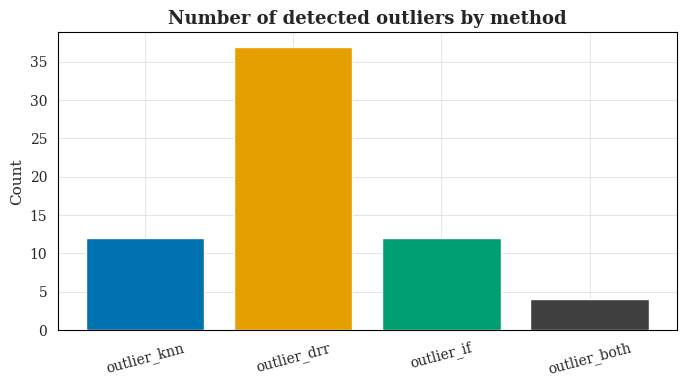

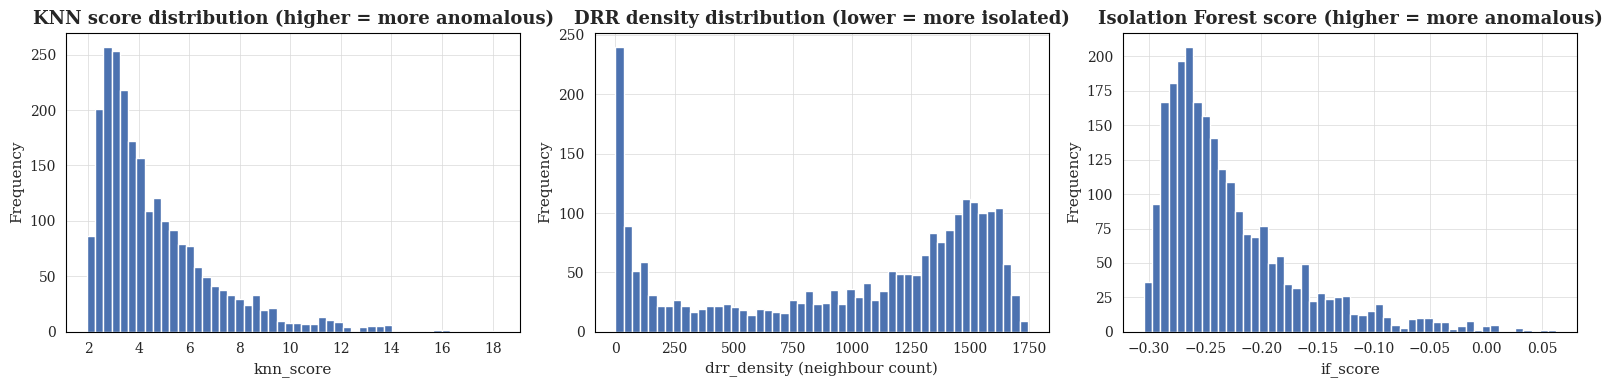

#### Top 10 by KNN score (highest)

,Edad,FR,SpO2,TAS,TAD,TAM,FC,TT,Lactato,Glucemia,FiO2,knn_score,drr_density,if_score,outlier_knn,outlier_drr,outlier_if,outlier_both
1944,77,29,60,72,41,51.333333,71,33.0,13.0,353,0.4,18.267726,0,-0.000024,True,True,False,False
1438,62,6,50,40,21,27.333333,267,34.5,12.1,102,1.0,16.374273,2,0.062406,True,True,True,True
2264,52,20,82,63,40,47.666667,62,35.5,3.5,600,1.0,16.304576,0,-0.035744,True,True,False,False
503,65,30,61,220,183,195.333333,112,37.5,6.7,131,1.0,16.090582,0,-0.002595,True,True,False,False
1154,68,8,91,122,97,105.333333,87,26.9,1.9,172,1.0,15.818577,0,-0.116071,True,True,False,False
1176,77,35,91,124,70,88.000000,132,38.9,5.1,640,1.0,15.780735,0,-0.068834,True,True,False,False
1384,22,5,60,70,30,43.333333,50,35.0,13.0,400,1.0,15.207978,2,0.052765,True,True,True,True
1541,19,4,50,140,54,82.666667,178,36.3,14.2,134,1.0,14.836272,0,0.007861,True,True,True,True
939,45,4,50,111,74,86.333333,150,36.5,5.7,454,1.0,14.464125,1,-0.000979,True,True,False,False
20,88,34,80,62,43,49.333333,165,36.8,7.9,450,0.5,14.027435,1,-0.017164,True,True,False,False


#### Top 10 by DRR density (lowest)

,Edad,FR,SpO2,TAS,TAD,TAM,FC,TT,Lactato,Glucemia,FiO2,knn_score,drr_density,if_score,outlier_knn,outlier_drr,outlier_if,outlier_both
1154,68,8,91,122,97,105.333333,87,26.9,1.9,172,1.0,15.818577,0,-0.116071,True,True,False,False
1541,19,4,50,140,54,82.666667,178,36.3,14.2,134,1.0,14.836272,0,0.007861,True,True,True,True
503,65,30,61,220,183,195.333333,112,37.5,6.7,131,1.0,16.090582,0,-0.002595,True,True,False,False
575,70,20,91,60,30,40.000000,180,35.8,5.6,330,0.5,12.030384,0,-0.046168,False,True,False,False
1753,82,40,52,146,55,85.333333,56,36.9,3.0,374,0.5,12.764020,0,-0.053796,False,True,False,False
1161,21,6,70,124,79,94.000000,240,34.6,3.8,166,1.0,12.951048,0,-0.042175,False,True,False,False
1176,77,35,91,124,70,88.000000,132,38.9,5.1,640,1.0,15.780735,0,-0.068834,True,True,False,False
2264,52,20,82,63,40,47.666667,62,35.5,3.5,600,1.0,16.304576,0,-0.035744,True,True,False,False
823,60,9,65,120,60,80.000000,70,35.8,6.9,550,1.0,13.793619,0,-0.053054,False,True,False,False
1944,77,29,60,72,41,51.333333,71,33.0,13.0,353,0.4,18.267726,0,-0.000024,True,True,False,False


#### Top 10 by Isolation Forest score (highest)

,Edad,FR,SpO2,TAS,TAD,TAM,FC,TT,Lactato,Glucemia,FiO2,knn_score,drr_density,if_score,outlier_knn,outlier_drr,outlier_if,outlier_both
1438,62,6,50,40,21,27.333333,267,34.5,12.1,102,1.0,16.374273,2,0.062406,True,True,True,True
1384,22,5,60,70,30,43.333333,50,35.0,13.0,400,1.0,15.207978,2,0.052765,True,True,True,True
2175,62,3,65,65,34,44.333333,234,34.0,12.8,132,1.0,13.820458,3,0.037603,False,False,True,False
1013,52,5,50,76,41,52.666667,114,34.1,11.4,404,1.0,13.761505,2,0.029000,False,True,True,False
1088,83,3,68,49,32,37.666667,178,34.9,8.9,248,1.0,12.087408,4,0.026588,False,False,True,False
279,72,6,60,67,32,43.666667,34,34.9,12.7,304,1.0,12.999093,2,0.025843,False,True,True,False
1031,60,4,50,67,34,45.000000,178,36.0,7.9,100,1.0,11.590065,8,0.008240,False,False,True,False
446,59,6,50,70,40,50.000000,150,37.2,6.0,338,1.0,12.817067,4,0.007989,False,False,True,False
1541,19,4,50,140,54,82.666667,178,36.3,14.2,134,1.0,14.836272,0,0.007861,True,True,True,True
303,91,6,50,56,34,41.333333,69,34.8,6.9,156,1.0,11.196660,4,0.006736,False,False,True,False


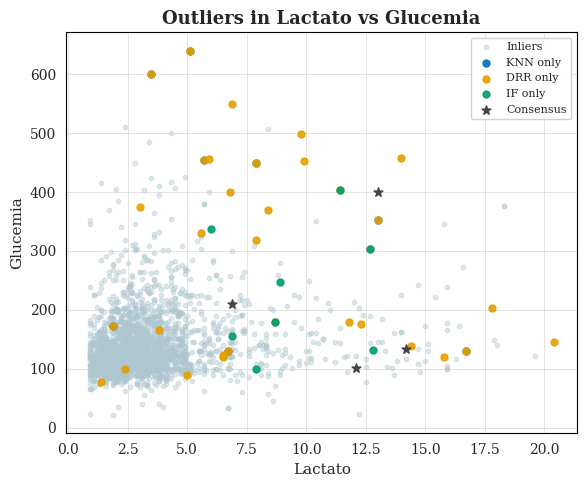

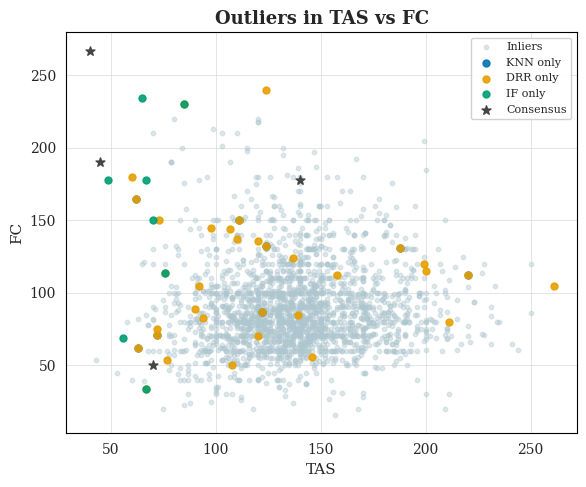

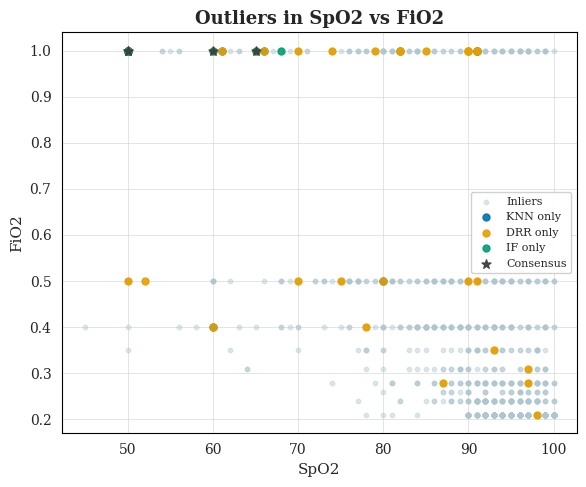

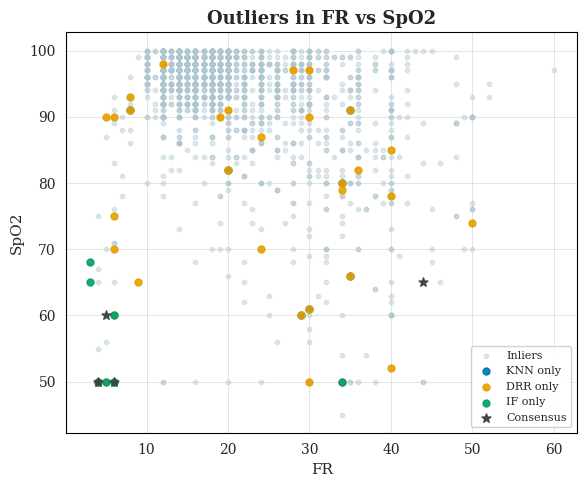

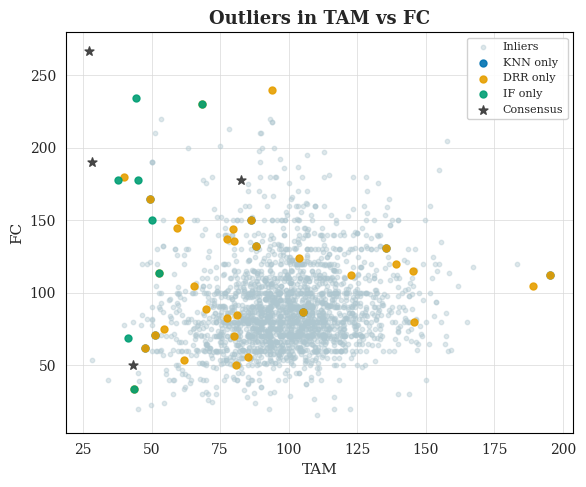

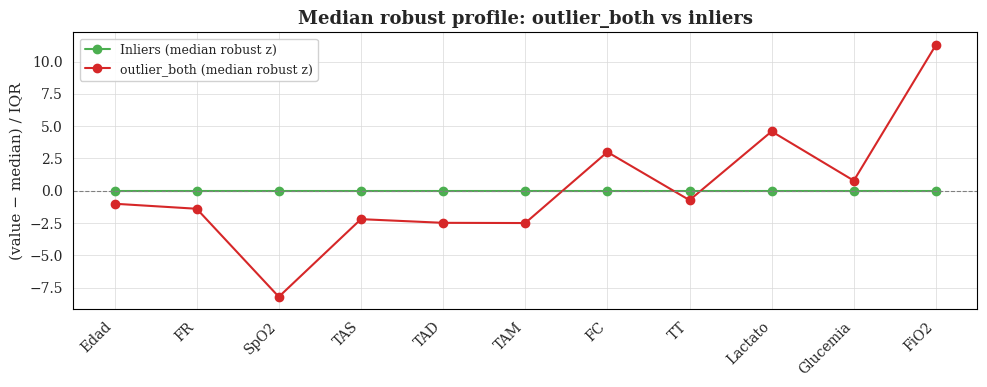

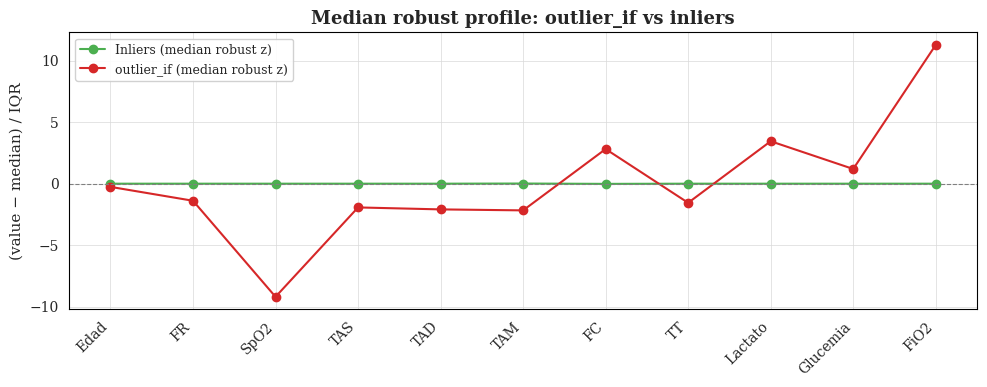

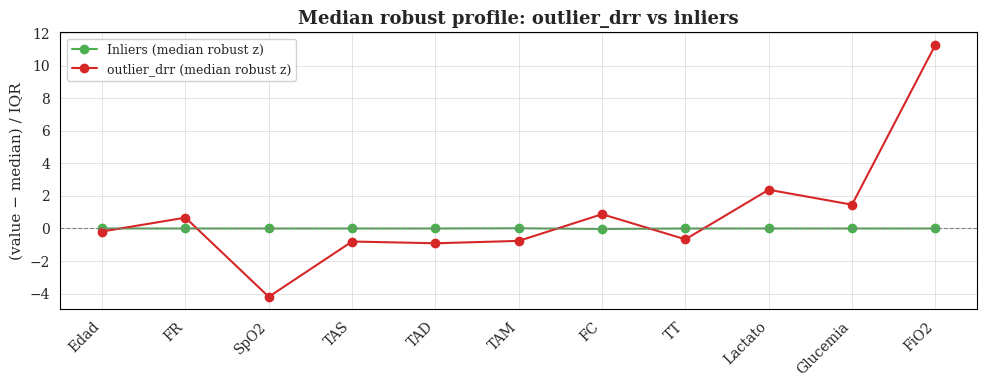

In [ ]:
def _get_mask(df: pd.DataFrame, col: str) -> np.ndarray:
    return df[col].astype(bool).values


def plot_outlier_counts(df_out: pd.DataFrame, save_path: Optional[str] = None) -> None:
    """Bar chart of outlier counts per method."""
    cols = ["outlier_knn", "outlier_drr", "outlier_if", "outlier_both"]
    counts = [int(_get_mask(df_out, c).sum()) for c in cols]
    plt.figure(figsize=(7, 4))
    plt.bar(cols, counts, color=[TFG_COLORS["cluster_0"], TFG_COLORS["cluster_1"], TFG_COLORS["cluster_2"], TFG_COLORS["cluster_consensus"]])
    plt.title("Number of detected outliers by method")
    plt.ylabel("Count")
    plt.xticks(rotation=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


def plot_score_histograms(df_out: pd.DataFrame, save_path: Optional[str] = None) -> None:
    """Histograms of KNN score, DRR density, and Isolation Forest score distributions."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(df_out["knn_score"].dropna(), bins=50)
    axes[0].set_title("KNN score distribution (higher = more anomalous)")
    axes[0].set_xlabel("knn_score")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(df_out["drr_density"].dropna(), bins=50)
    axes[1].set_title("DRR density distribution (lower = more isolated)")
    axes[1].set_xlabel("drr_density (neighbour count)")
    axes[1].set_ylabel("Frequency")

    axes[2].hist(df_out["if_score"].dropna(), bins=50) #color="#70ad47"
    axes[2].set_title("Isolation Forest score (higher = more anomalous)")
    axes[2].set_xlabel("if_score")
    axes[2].set_ylabel("Frequency")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


def plot_top_outliers_table(
    df_out: pd.DataFrame,
    used_numeric_cols: List[str],
    top_n: int = 10,
    save_dir: Optional[str] = None,
) -> None:
    """Display the top-N most extreme cases by KNN score, DRR density, and IF score."""
    show_cols = used_numeric_cols + [
        "knn_score", "drr_density", "if_score",
        "outlier_knn", "outlier_drr", "outlier_if", "outlier_both",
    ]
    knn_top = df_out.sort_values("knn_score", ascending=False).head(top_n)[show_cols]
    display(Markdown(f"#### Top {top_n} by KNN score (highest)"))
    display(knn_top)

    drr_top = df_out.sort_values("drr_density", ascending=True).head(top_n)[show_cols]
    display(Markdown(f"#### Top {top_n} by DRR density (lowest)"))
    display(drr_top)

    if_top = df_out.sort_values("if_score", ascending=False).head(top_n)[show_cols]
    display(Markdown(f"#### Top {top_n} by Isolation Forest score (highest)"))
    display(if_top)

    if save_dir:
        knn_top.to_csv(os.path.join(save_dir, "tbl_09a_top_outliers_knn.csv"))
        drr_top.to_csv(os.path.join(save_dir, "tbl_09b_top_outliers_drr.csv"))
        if_top.to_csv(os.path.join(save_dir, "tbl_09c_top_outliers_if.csv"))


def plot_pairwise_scatter(df_out: pd.DataFrame, x: str, y: str,
                          save_path: Optional[str] = None) -> None:
    """2D scatter coloured by outlier category (inlier, KNN-only, DRR-only, IF-only, consensus)."""
    any_flag  = df_out["outlier_knn"] | df_out["outlier_drr"] | df_out["outlier_if"]
    in_mask   = ~any_flag
    knn_mask  = df_out["outlier_knn"] & ~df_out["outlier_both"]
    drr_mask  = df_out["outlier_drr"] & ~df_out["outlier_both"]
    if_mask   = df_out["outlier_if"]  & ~df_out["outlier_both"]
    both_mask = df_out["outlier_both"]

    plt.figure(figsize=(6, 5))
    plt.scatter(df_out.loc[in_mask, x],   df_out.loc[in_mask, y],
                s=10, alpha=0.4, label="Inliers",     color=TFG_COLORS["inliers"])
    plt.scatter(df_out.loc[knn_mask, x],  df_out.loc[knn_mask, y],
                s=25, alpha=0.9, label="KNN only",    color=TFG_COLORS["cluster_0"])
    plt.scatter(df_out.loc[drr_mask, x],  df_out.loc[drr_mask, y],
                s=25, alpha=0.9, label="DRR only",    color=TFG_COLORS["cluster_1"])
    plt.scatter(df_out.loc[if_mask, x],   df_out.loc[if_mask, y],
                s=25, alpha=0.9, label="IF only",     color=TFG_COLORS["cluster_2"])
    plt.scatter(df_out.loc[both_mask, x], df_out.loc[both_mask, y],
                s=45, alpha=0.95, label="Consensus",  color=TFG_COLORS["cluster_consensus"], marker="*")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"Outliers in {x} vs {y}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


def plot_outlier_profile_radar_like(
    df_out: pd.DataFrame,
    used_numeric_cols: List[str],
    which: str = "outlier_both",
    save_path: Optional[str] = None,
) -> None:
    """Median robust z-score profile: outliers vs inliers."""
    out_mask = df_out[which].astype(bool)
    in_mask  = ~out_mask

    med = df_out[used_numeric_cols].median(numeric_only=True)
    q1  = df_out[used_numeric_cols].quantile(0.25, numeric_only=True)
    q3  = df_out[used_numeric_cols].quantile(0.75, numeric_only=True)
    iqr = (q3 - q1).replace(0, np.nan)

    z_out = ((df_out.loc[out_mask, used_numeric_cols] - med) / iqr).median()
    z_in  = ((df_out.loc[in_mask,  used_numeric_cols] - med) / iqr).median()

    plt.figure(figsize=(10, 4))
    plt.plot(used_numeric_cols, z_in.values,  marker="o", color=TFG_COLORS["alive_leaf"], label="Inliers (median robust z)")
    plt.plot(used_numeric_cols, z_out.values, marker="o", color=TFG_COLORS["ref_line"], label=f"{which} (median robust z)")
    plt.axhline(0, color="grey", lw=0.8, linestyle="--")
    plt.title(f"Median robust profile: {which} vs inliers")
    plt.ylabel("(value − median) / IQR")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


# ── Run all diagnostic plots ────────────────────────────────────────────────
plot_outlier_counts(df_out, save_path=os.path.join(NB3_OUTPUT_DIR, "fig_09a_outlier_counts.png"))
plot_score_histograms(df_out, save_path=os.path.join(NB3_OUTPUT_DIR, "fig_09b_score_histograms.png"))
plot_top_outliers_table(df_out, used_numeric_cols, top_n=10, save_dir=NB3_OUTPUT_DIR)

SCATTER_PAIRS = [
    ("Lactato", "Glucemia"),
    ("TAS", "FC"),
    ("SpO2", "FiO2"),
    ("FR", "SpO2"),
    ("TAM", "FC"),
]
for x, y in SCATTER_PAIRS:
    if x in df_out.columns and y in df_out.columns:
        _sp = os.path.join(NB3_OUTPUT_DIR, f"fig_09c_scatter_{x}_{y}.png")
        plot_pairwise_scatter(df_out, x, y, save_path=_sp)

plot_outlier_profile_radar_like(df_out, used_numeric_cols, which="outlier_both",
    save_path=os.path.join(NB3_OUTPUT_DIR, "fig_09d_profile_consensus.png"))
plot_outlier_profile_radar_like(df_out, used_numeric_cols, which="outlier_if",
    save_path=os.path.join(NB3_OUTPUT_DIR, "fig_09e_profile_if.png"))
plot_outlier_profile_radar_like(df_out, used_numeric_cols, which="outlier_drr",
    save_path=os.path.join(NB3_OUTPUT_DIR, "fig_09f_profile_drr.png"))

## **10. Plausibility and coherence audit**

Before deciding whether to retain, correct, or remove outliers, their clinical plausibility is assessed through **cross-variable coherence rules**. These rules check whether the values of related variables are internally consistent, they do not enforce normal ranges but rather flag physiologically contradictory combinations.

### Function: `plausibility_coherence_flags(df)`

| Parameter | Type | Description |
|-----------|------|-------------|
| `df` | `pd.DataFrame` | Dataset with clinical variables |
| **Returns** | `pd.DataFrame` | Boolean flags per rule + aggregate `any_coherence_issue` |

**Rules implemented**:

| Rule ID | Variables | Condition flagged | Clinical rationale |
|---------|-----------|-------------------|--------------------|
| `bp_tas_lt_tad` | TAS, TAD | TAS < TAD | Systolic pressure should always exceed diastolic |
| `map_inconsistent` | TAS, TAD, TAM | \|TAM − (TAS + 2·TAD)/3\| > 25 | MAP estimate should roughly match the measured value (tolerance 25 mmHg accounts for non-simultaneous measurement) |
| `hypox_low_fio2` | SpO2, FiO2 | SpO2 ≤ 80 and FiO2 ≤ 0.25 | Severe hypoxemia on near room-air is possible but warrants review |
| `high_fio2_high_spo2` | SpO2, FiO2 | FiO2 ≥ 0.90 and SpO2 ≥ 98 | High O2 delivery with near-normal saturation — plausible treatment state but notable |
| `fr_zero_fc_normal` | FR, FC | FR = 0 and 50 ≤ FC ≤ 110 | Zero respiratory rate with normal heart rate suggests a recording artefact |

> The coherence audit is the critical step that distinguishes **clinically valid extreme cases** (which must be retained for accurate modelling) from **data quality errors** (which should be corrected or removed). If no detected outlier violates any coherence rule, the evidence supports retention.

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `coh` | `pd.DataFrame` | Coherence flags for all rows |
| `coh_out` | `pd.DataFrame` | Coherence flags restricted to detected outliers only |
| Console output | | Count and rate of coherence issues among outliers |

In [ ]:
def plausibility_coherence_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Apply cross-variable coherence checks to flag suspicious combinations.

    These are review-level flags, not definitive errors — measurements may
    be non-synchronous in prehospital settings.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset with clinical variables.

    Returns
    -------
    pd.DataFrame
        Boolean flags per rule, plus 'any_coherence_issue' aggregate.
    """
    flags = pd.DataFrame(index=df.index)

    # 1) TAS should be ≥ TAD
    if "TAS" in df.columns and "TAD" in df.columns:
        flags["bp_tas_lt_tad"] = (
            df["TAS"].notna() & df["TAD"].notna() & (df["TAS"] < df["TAD"])
        )
    else:
        flags["bp_tas_lt_tad"] = False

    # 2) MAP consistency (±25 mmHg tolerance)
    if all(c in df.columns for c in ["TAS", "TAD", "TAM"]):
        map_est = (df["TAS"] + 2 * df["TAD"]) / 3.0
        flags["map_inconsistent"] = (
            df["TAM"].notna() & map_est.notna()
            & (np.abs(df["TAM"] - map_est) > 25)
        )
    else:
        flags["map_inconsistent"] = False

    # 3) Oxygenation patterns
    if "SpO2" in df.columns and "FiO2" in df.columns:
        flags["hypox_low_fio2"] = (
            df["SpO2"].notna() & df["FiO2"].notna()
            & (df["SpO2"] <= 80) & (df["FiO2"] <= 0.25)
        )
        flags["high_fio2_high_spo2"] = (
            df["SpO2"].notna() & df["FiO2"].notna()
            & (df["FiO2"] >= 0.90) & (df["SpO2"] >= 98)
        )
    else:
        flags["hypox_low_fio2"]     = False
        flags["high_fio2_high_spo2"] = False

    # 4) FR = 0 with normal heart rate → possible recording artefact
    if "FR" in df.columns and "FC" in df.columns:
        flags["fr_zero_fc_normal"] = (
            df["FR"].notna() & df["FC"].notna()
            & (df["FR"] == 0) & df["FC"].between(50, 110)
        )
    else:
        flags["fr_zero_fc_normal"] = False

    # Aggregate
    rule_cols = [c for c in flags.columns]
    flags["any_coherence_issue"] = flags[rule_cols].any(axis=1)
    return flags


# --- Apply to detected outliers ---
coh = plausibility_coherence_flags(df_out)
out_mask = df_out["outlier_knn"] | df_out["outlier_drr"]
coh_out  = coh.loc[out_mask]

display(Markdown("### Coherence issue rate among detected outliers"))
display(coh_out.mean().to_frame("rate"))

n_issues = int(coh_out["any_coherence_issue"].sum())
n_outliers = int(out_mask.sum())
display(Markdown(f"**Outliers with ≥1 coherence issue:** {n_issues} / {n_outliers}"))

coh_rates_df = coh.mean().sort_values(ascending=False).to_frame("rate")
display(Markdown("### Coherence issue rate in full dataset (context)"))
display(coh_rates_df)
coh_rates_df.to_csv(os.path.join(NB3_OUTPUT_DIR, "tbl_10_coherence_rates.csv"))

# Show flagged outliers (if any)
issues = coh_out.loc[coh_out["any_coherence_issue"]]
if len(issues):
    display(Markdown(f"### Outliers with coherence flags ({len(issues)} cases)"))
    show_cols = used_numeric_cols + OUTLIER_FLAG_COLS
    display(
        df_out.loc[issues.index, show_cols]
        .join(coh.loc[issues.index])
        .head(30)
    )
else:
    display(Markdown("✅ **No coherence violations among detected outliers.**"))

### Coherence issue rate among detected outliers

,rate
bp_tas_lt_tad,0.0
map_inconsistent,0.0
hypox_low_fio2,0.0
high_fio2_high_spo2,0.0
fr_zero_fc_normal,0.0
any_coherence_issue,0.0


**Outliers with ≥1 coherence issue:** 0 / 37

### Coherence issue rate in full dataset (context)

,rate
any_coherence_issue,0.005471
high_fio2_high_spo2,0.003788
hypox_low_fio2,0.001263
map_inconsistent,0.000421
bp_tas_lt_tad,0.000000
fr_zero_fc_normal,0.000000


✅ **No coherence violations among detected outliers.**

## **11. Driver analysis — robust z-scores**


For each detected outlier, identify **which variables** contribute most to its anomalous status by computing robust z-scores:

$$z_{\text{robust}} = \frac{x - \text{median}}{\text{IQR}}$$

This is not a formal statistical z-score but a robust effect-size indicator: values > 3 indicate substantial deviation from the cohort median relative to the interquartile range.

The top-3 absolute deviations per row are reported as the outlier's **drivers**, e.g., `FiO2(+11.29), SpO2(−6.20), Lactato(+4.48)`.

### Function: `robust_zscores(df, cols)`

| Parameter | Type | Description |
|-----------|------|-------------|
| `df` | `pd.DataFrame` | Dataset |
| `cols` | `List[str]` | Numeric column names |
| **Returns** | `pd.DataFrame` | Robust z-scores (same shape as input subset) |

### Function: `top_drivers_per_row(z_df, top_n)`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `z_df` | `pd.DataFrame` | — | Robust z-score matrix |
| `top_n` | `int` | `3` | Number of top drivers to report per row |
| **Returns** | `pd.Series` | | String column listing the top-N drivers with signed z-values |

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `audit_table` | `pd.DataFrame` | Detected outliers with raw values, flags, coherence results, and top-3 drivers |

In [ ]:
def robust_zscores(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """Compute robust z-scores using median and IQR.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset.
    cols : List[str]
        Numeric column names.

    Returns
    -------
    pd.DataFrame
        Robust z-scores for each cell.
    """
    cols = [c for c in cols if c in df.columns]
    med = df[cols].median(numeric_only=True)
    q1  = df[cols].quantile(0.25, numeric_only=True)
    q3  = df[cols].quantile(0.75, numeric_only=True)
    iqr = (q3 - q1).replace(0, np.nan)
    return (df[cols] - med) / iqr


def top_drivers_per_row(z_df: pd.DataFrame, top_n: int = 3) -> pd.Series:
    """Identify the top-N absolute z-score drivers per row.

    Parameters
    ----------
    z_df : pd.DataFrame
        Robust z-score matrix.
    top_n : int
        Number of drivers to report.

    Returns
    -------
    pd.Series
        String per row, e.g. 'FiO2(+11.29), SpO2(-6.20), Lactato(+4.48)'.
    """
    drivers = []
    for _, row in z_df.iterrows():
        s = row.dropna()
        if s.empty:
            drivers.append("")
            continue
        top = s.reindex(s.abs().sort_values(ascending=False).head(top_n).index)
        drivers.append(", ".join([f"{c}({top[c]:+.2f})" for c in top.index]))
    return pd.Series(drivers, index=z_df.index, name="top_drivers")


# --- Compute driver analysis for all detected outliers ---
z = robust_zscores(df_out, used_numeric_cols)
drivers = top_drivers_per_row(z, top_n=3)

audit_table = (
    df_out.loc[out_mask, used_numeric_cols + OUTLIER_FLAG_COLS]
    .join(coh.loc[out_mask])
    .join(drivers.loc[out_mask])
)

display(Markdown("### Outlier audit table (first 30 rows)"))
display(audit_table.head(30))
audit_table.to_csv(os.path.join(NB3_OUTPUT_DIR, "tbl_11_outlier_audit.csv"))

### Outlier audit table (first 30 rows)

,Edad,FR,SpO2,TAS,TAD,TAM,FC,TT,Lactato,Glucemia,FiO2,outlier_knn,outlier_drr,outlier_if,outlier_both,bp_tas_lt_tad,map_inconsistent,hypox_low_fio2,high_fio2_high_spo2,fr_zero_fc_normal,any_coherence_issue,top_drivers
20,88,34,80,62,43,49.333333,165,36.8,7.9,450,0.50,True,True,False,False,False,False,False,False,False,False,"Glucemia(+5.75), FiO2(+4.14), SpO2(-3.20)"
275,70,35,66,188,109,135.333333,131,34.5,16.7,131,1.00,True,True,False,False,False,False,False,False,False,False,"FiO2(+11.29), Lactato(+6.57), SpO2(-6.00)"
278,93,8,93,98,40,59.333333,145,35.3,9.8,498,0.35,False,True,False,False,False,False,False,False,False,False,"Glucemia(+6.61), Lactato(+3.29), FiO2(+2.00)"
279,72,6,60,67,32,43.666667,34,34.9,12.7,304,1.00,False,True,True,False,False,False,False,False,False,False,"FiO2(+11.29), SpO2(-7.20), Lactato(+4.67)"
436,89,40,78,92,52,65.333333,105,35.2,5.9,456,0.40,False,True,False,False,False,False,False,False,False,False,"Glucemia(+5.86), SpO2(-3.60), FiO2(+2.71)"
442,47,6,90,90,60,70.000000,89,35.4,9.9,452,0.50,False,True,False,False,False,False,False,False,False,False,"Glucemia(+5.79), FiO2(+4.14), Lactato(+3.33)"
454,85,30,50,158,105,122.666667,112,35.8,7.9,318,1.00,False,True,False,False,False,False,False,False,False,False,"FiO2(+11.29), SpO2(-9.20), Glucemia(+3.39)"
503,65,30,61,220,183,195.333333,112,37.5,6.7,131,1.00,True,True,False,False,False,False,False,False,False,False,"FiO2(+11.29), SpO2(-7.00), TAD(+4.68)"
510,48,4,50,110,61,77.333333,137,38.5,6.5,120,0.50,False,True,False,False,False,False,False,False,False,False,"SpO2(-9.20), FiO2(+4.14), TT(+2.44)"
575,70,20,91,60,30,40.000000,180,35.8,5.6,330,0.50,False,True,False,False,False,False,False,False,False,False,"FiO2(+4.14), Glucemia(+3.61), FC(+2.88)"


## **12. Final decision — outlier retention**

### Results summary

The combined outlier detection and audit pipeline produced the following findings:

1. **KNN** flagged approximately **0.5 %** of the cohort as extreme outliers (globally isolated in the scaled feature space).
2. **DRR** flagged a broader set of approximately **1.6 %** (locally sparse density).
3. **Isolation Forest** flagged the same fraction as KNN (shared parameter `IF_CONTAMINATION = best_knn.contamination`; exact rate printed at the end of Section 7 execution).
4. **All KNN outliers were contained within the DRR set**, confirming methodological consistency between distance-based methods.
5. **Tri-method consensus** (`outlier_both`) retains only observations flagged simultaneously by KNN, DRR, and Isolation Forest — the most conservative subset.
6. **No coherence violations** were found among the detected outliers — all extreme values represent internally consistent clinical profiles.
7. **Driver analysis** revealed that outlier status is primarily driven by extreme but plausible patterns in oxygenation (low SpO2 + high FiO2) and metabolic variables (elevated Lactato and Glucemia), consistent with critically ill patients.

### Decision

**No corrective action** (removal, winsorisation, or imputation) is applied. All detected outliers are retained in the dataset as clinically plausible extreme cases. The binary flags (`outlier_knn`, `outlier_drr`, `outlier_if`, `outlier_both`) are preserved for traceability and can be used for sensitivity analyses in **NB4** (e.g., comparing model performance with and without outliers).



> Removing clinically valid extreme cases would:
> - Reduce the representation of high-risk patients in the dataset, biasing mortality prediction models.
> - Violate the principle that a clinical scoring system (**NB4**) must perform well across the full severity spectrum.
> - Discard rare but informative signals that contribute to model discrimination.

### Output

The dataset passed to NB4 is the original `dataset_CLEAN.csv` from NB1 — unmodified. The outlier analysis in this notebook is diagnostic only.

## **13. Conclusions**
### What was achieved

1. **Numeric variable selection** — 11 prehospital vital signs and lab values identified programmatically from the attribute reference table.
2. **Preprocessing** — median imputation + IQR-based scaling (RobustScaler) to prepare a distance-meaningful feature space.
3. **KNN outlier detection** — calibrated over k ∈ {5, 10, 15, 20, 30} and contamination ∈ {0.5 %, 1 %, 2 %}, selecting the configuration with the highest outlier–inlier separation gap.
4. **DRR outlier detection** — calibrated over data-driven radii (KNN distance percentiles) with the same contamination grid.
5. **Isolation Forest outlier detection** — ensemble of 200 isolation trees fitted with shared contamination parameter; anomaly scores derived by negating the decision function for directional consistency with KNN.
6. **Tri-method consensus flagging** — four levels of outlier confidence: KNN-only, DRR-only, IF-only, and tri-method consensus (`outlier_both`), with consensus being the most conservative.
7. **Diagnostic visualisation** — 6 plot types providing complementary views of outlier characteristics across all three methods.
8. **Plausibility audit** — 5 cross-variable coherence rules verified no data quality issues among detected outliers.
9. **Driver analysis** — robust z-scores identified the variables responsible for each outlier's anomalous status, run separately for KNN, DRR, and Isolation Forest flags.